In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

import zuko
import torch

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Dataset preparation

## Natural disaster datasets

### Load and clean the datasets

In [2]:
# Define paths to the storm events CSV files
data_dir = Path('datasets')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [3]:
useless_cols = [
    'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID', 'EVENT_ID',
    'SOURCE',
    'YEAR',
    'MONTH_NAME',
    'WFO',
    'CATEGORY',
    'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME',
    'CZ_NAME', 'CZ_TIMEZONE',
    'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE',
    
    'FLOOD_CAUSE',
    'TOR_LENGTH',
    'TOR_WIDTH',
    'BEGIN_RANGE',
    'BEGIN_AZIMUTH',
    'BEGIN_LOCATION',
    'END_RANGE',
    'END_AZIMUTH',
    'END_LOCATION',
    'END_LAT',
    'END_LON',
    'MAGNITUDE_TYPE',
    'TOR_F_SCALE',
]

df1 = df.drop(columns=useless_cols, inplace=False)

In [4]:
df1.columns

Index(['STATE', 'STATE_FIPS', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS',
       'BEGIN_DATE_TIME', 'END_DATE_TIME', 'INJURIES_DIRECT',
       'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT',
       'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'MAGNITUDE', 'BEGIN_LAT',
       'BEGIN_LON'],
      dtype='object')

### Aggregate features

In [5]:
df1['EVENT_TYPE'] = df1['EVENT_TYPE'].replace({
    'Thunderstorm Wind': 'Wind',
    'Hail': 'Hail',
    'Marine Hail': 'Hail',
    'Flood': 'Flood',
    'Flash Flood': 'Flood',
    'Coastal Flood': 'Flood',
    'Lakeshore Flood': 'Flood',
    'Winter Weather': 'Freeze',
    'Extreme Cold/Wind Chill': 'Freeze',
    'Frost/Freeze': 'Freeze',
    'Cold/Wind Chill': 'Freeze',
    'Freezing Fog': 'Freeze',
    'Heat': 'Heat',
    'Excessive Heat': 'Heat',
    'Heavy Snow': 'Snow',
    'Blizzard': 'Snow',
    'Lake-Effect Snow': 'Snow',
    'Sleet': 'Snow',
    'Winter Storm': 'Storm',
    'Marine Thunderstorm Wind': 'Storm',
    'Tornado': 'Storm',
    'Tropical Storm': 'Storm',
    'Dust Storm': 'Storm',
    'Funnel Cloud': 'Storm',
    'Ice Storm': 'Storm',
    'Waterspout': 'Storm',
    'Marine Tropical Storm': 'Storm',
    'Hurricane (Typhoon)': 'Storm',
    'Marine Hurricane/Typhoon': 'Storm',
    'High Wind':  'Wind',
    'Strong Wind':  'Wind',
    'Marine High Wind':  'Wind',
    'Marine Strong Wind':  'Wind',
    'Dense Fog':  'Fog',
    'Marine Dense Fog':  'Fog'
})

In [6]:
def damage_to_numeric(damage_str):
    if pd.isna(damage_str):
        return 0
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}
    if damage_str[-1] in multipliers:
        try:
            value = float(damage_str[:-1])
            return value * multipliers[damage_str[-1]]
        except ValueError:
            return 0
    try:
        return float(damage_str)
    except ValueError:
        return 0   

df1['DAMAGES'] = df1['DAMAGE_PROPERTY'].apply(damage_to_numeric) + df1['DAMAGE_CROPS'].apply(damage_to_numeric)
df2 = df1.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=False)

In [7]:
df2['CASUALTIES'] = df2['INJURIES_DIRECT'].fillna(0) + df2['INJURIES_INDIRECT'].fillna(0) + df2['DEATHS_DIRECT'].fillna(0) + df2['DEATHS_INDIRECT'].fillna(0)
df3 = df2.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=False)

Actually keep only few events type for first experiments

In [8]:
df2['EVENT_TYPE'].unique()

array(['Heavy Rain', 'Wind', 'Storm', 'Heat', 'Flood', 'Drought', 'Hail',
       'Freeze', 'Lightning', 'Wildfire', 'Snow', 'Fog', 'Avalanche',
       'High Surf', 'Debris Flow', 'Astronomical Low Tide', 'Rip Current',
       'Dust Devil', 'Storm Surge/Tide', 'Sneakerwave',
       'Marine Tropical Depression', 'Seiche', 'Tropical Depression',
       'Dense Smoke', 'Volcanic Ashfall', 'Tsunami'], dtype=object)

In [9]:
df3 = df3[df3['EVENT_TYPE'].isin(['Flood', 'Tornado', 'Hail', 'Storm', 'Tsunami', 'Freeze', 'Snow', 'Heat', 'Heavy Rain', 'Wildfire'])]

In [10]:
df3['EVENT_TYPE'].nunique()

9

### Create unique FIPS

Unique FIPS is created starting from FIPS state (2 numbers) + FIPS county (3 numbers) (fill with zero the entry with less than this numbers)

In [11]:
df3['FIPS'] = df3['STATE_FIPS'].astype(str).str.zfill(2) + df3['CZ_FIPS'].astype(str).str.zfill(3)
print(df3[['FIPS', 'STATE_FIPS', 'CZ_FIPS']].head(10))

     FIPS  STATE_FIPS  CZ_FIPS
0   45091          45       91
6   56001          56        1
7   56012          56       12
8   56013          56       13
9   92247          92      247
10  92263          92      263
14  09001           9        1
15  09013           9       13
19  36093          36       93
23  09013           9       13


In [12]:
df3.drop(columns=['STATE_FIPS', 'CZ_FIPS'], inplace=True)

### Encode features

In [13]:
# categorial -> numeric
df3['EVENT_TYPE'] = df3['EVENT_TYPE'].astype('category').cat.codes

In [14]:
# EVENT_TYPE one-hot encoding
enc = OneHotEncoder(sparse_output=False)
event_type_encoded = enc.fit_transform(df3[['EVENT_TYPE']])
event_type_df = pd.DataFrame(event_type_encoded, columns=[f"EVENT_TYPE_{cat}" for cat in enc.categories_[0]], index=df3.index)
                             
df4 = pd.concat([df3.drop(columns=['EVENT_TYPE'], inplace=False), event_type_df], axis=1)

In [15]:
df4.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,MAGNITUDE,BEGIN_LAT,BEGIN_LON,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,EVENT_TYPE_7,EVENT_TYPE_8
0,SOUTH CAROLINA,C,15-JUL-16 17:15:00,15-JUL-16 17:15:00,NaN,34.940,-81.030,2000.0,0,45091,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,WYOMING,Z,04-DEC-16 03:00:00,05-DEC-16 06:00:00,NaN,NaN,NaN,0.0,0,56001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,WYOMING,Z,04-DEC-16 04:00:00,05-DEC-16 05:00:00,NaN,NaN,NaN,0.0,0,56012,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,WYOMING,Z,04-DEC-16 04:00:00,05-DEC-16 05:00:00,NaN,NaN,NaN,0.0,0,56013,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,LAKE SUPERIOR,Z,12-JUL-16 01:30:00,12-JUL-16 01:35:00,41.0,46.969,-88.398,0.0,0,92247,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
# fill BEGIN_LAT and BEGIN_LON NaN values with the mean of their respective columns
df4['BEGIN_LAT'] = df4['BEGIN_LAT'].fillna(df4['BEGIN_LAT'].mean())
df4['BEGIN_LON'] = df4['BEGIN_LON'].fillna(df4['BEGIN_LON'].mean())

In [17]:
# encode time cols BEGIN_DATE_TIME and END_DATE_TIME
fmt = "%d-%b-%y %H:%M:%S"

df4['BEGIN_DATE_TIME'] = pd.to_datetime(df4['BEGIN_DATE_TIME'], format=fmt, errors='coerce')
df4['END_DATE_TIME'] = pd.to_datetime(df4['END_DATE_TIME'], format=fmt, errors='coerce')

 # Extract hour and day of year
for prefix in ['BEGIN', 'END']:
    dt_col = f'{prefix}_DATE_TIME'
    # Hour of day cyclical encoding
    df4[f'{prefix}_HOUR_sin'] = np.sin(2 * np.pi * df4[dt_col].dt.hour / 24)
    df4[f'{prefix}_HOUR_cos'] = np.cos(2 * np.pi * df4[dt_col].dt.hour / 24)
    # Day of year cyclical encoding
    df4[f'{prefix}_DOY_sin'] = np.sin(2 * np.pi * df4[dt_col].dt.dayofyear / 366)
    df4[f'{prefix}_DOY_cos'] = np.cos(2 * np.pi * df4[dt_col].dt.dayofyear / 366)

# Optionally drop original datetime columns
# df.drop(columns=['BEGIN_DATE_TIME', 'END_DATE_TIME'], inplace=True)

In [18]:
df4.columns

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'MAGNITUDE',
       'BEGIN_LAT', 'BEGIN_LON', 'DAMAGES', 'CASUALTIES', 'FIPS',
       'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2', 'EVENT_TYPE_3',
       'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6', 'EVENT_TYPE_7',
       'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos', 'BEGIN_DOY_sin',
       'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos', 'END_DOY_sin',
       'END_DOY_cos'],
      dtype='object')

In [19]:
df4.drop(columns=['MAGNITUDE', 'BEGIN_LAT', 'BEGIN_LON'], inplace=True)

In [20]:
df5 = df4[df4['CZ_TYPE'] == 'C'] # keep only disasters happend in a county (for which we have demographical information)

In [21]:
nd_df = df5.copy()
nd_df.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,...,EVENT_TYPE_7,EVENT_TYPE_8,BEGIN_HOUR_sin,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos
0,SOUTH CAROLINA,C,2016-07-15 17:15:00,2016-07-15 17:15:00,2000.0,0,45091,0.0,0.0,0.0,...,0.0,0.0,-0.965926,-0.258819,-0.238033,-0.971257,-0.965926,-2.588190e-01,-0.238033,-0.971257
19,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
28,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
29,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
30,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864


In [22]:
nd_df.columns

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES',
       'CASUALTIES', 'FIPS', 'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2',
       'EVENT_TYPE_3', 'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6',
       'EVENT_TYPE_7', 'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos',
       'BEGIN_DOY_sin', 'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos',
       'END_DOY_sin', 'END_DOY_cos'],
      dtype='object')

### Normalize features

In [23]:
scaler = StandardScaler()

## County population datasets

In [24]:
url_county = data_dir / 'cc-est2024-alldata.csv'
cs_df1 = pd.read_csv(url_county, encoding='latin1')

In [25]:
cs_df1.head()

,SUMLEV,STATE,COUNTY,STNAME,CTYNAME,YEAR,AGEGRP,TOT_POP,TOT_MALE,TOT_FEMALE,...,HWAC_MALE,HWAC_FEMALE,HBAC_MALE,HBAC_FEMALE,HIAC_MALE,HIAC_FEMALE,HAAC_MALE,HAAC_FEMALE,HNAC_MALE,HNAC_FEMALE
0,50,1,1,Alabama,Autauga County,1,0,58800,28693,30107,...,963,844,132,116,42,33,22,25,19,10
1,50,1,1,Alabama,Autauga County,1,1,3491,1818,1673,...,93,60,17,11,3,0,11,1,3,0
2,50,1,1,Alabama,Autauga County,1,2,3663,1875,1788,...,92,77,6,9,9,4,0,1,1,2
3,50,1,1,Alabama,Autauga County,1,3,4189,2152,2037,...,94,93,12,13,1,3,2,2,3,1
4,50,1,1,Alabama,Autauga County,1,4,3876,1960,1916,...,79,79,9,11,5,3,2,4,3,2


In [26]:
url_landmass = data_dir / 'county_landmass.csv'
lm_df1 = pd.read_csv(url_landmass)

In [27]:
lm_df1.head()

,FIPS,FIPS_state,FIPS_county,state_abbrev,state,county,sq_mi,land_sq_mi,water_sq_mi
0,1001,1,1,AL,Alabama,Autauga,604.45,595.97,8.48
1,1003,1,3,AL,Alabama,Baldwin,2026.93,1596.35,430.58
2,1005,1,5,AL,Alabama,Barbour,904.52,884.90,19.61
3,1007,1,7,AL,Alabama,Bibb,626.16,623.03,3.14
4,1009,1,9,AL,Alabama,Blount,650.60,645.59,5.02


### Create unique FIPS

In [28]:
cs_df1['FIPS'] = cs_df1['STATE'].astype(str).str.zfill(2) + cs_df1['COUNTY'].astype(str).str.zfill(3)
print(cs_df1[['FIPS', 'STATE', 'COUNTY']].head(10))

    FIPS  STATE  COUNTY
0  01001      1       1
1  01001      1       1
2  01001      1       1
3  01001      1       1
4  01001      1       1
5  01001      1       1
6  01001      1       1
7  01001      1       1
8  01001      1       1
9  01001      1       1


In [29]:
lm_df1['FIPS'] = lm_df1['FIPS_state'].astype(str).str.zfill(2) + lm_df1['FIPS_county'].astype(str).str.zfill(3)
print(lm_df1[['FIPS', 'FIPS_state', 'FIPS_county']].head(10))

    FIPS  FIPS_state  FIPS_county
0  01001           1            1
1  01003           1            3
2  01005           1            5
3  01007           1            7
4  01009           1            9
5  01011           1           11
6  01013           1           13
7  01015           1           15
8  01017           1           17
9  01019           1           19


### Keep only useful columns

In [30]:
cs_df2 = cs_df1[cs_df1['YEAR'] == 2]    # Keep only one population estimation for a fixed year (2020)
cs_df3 = cs_df2[cs_df2['AGEGRP'] == 0]  # Keep only the total population estimation per county (all races, all ages,...)
print(cs_df3.shape, cs_df2.shape, cs_df1.shape)

(3144, 81) (59736, 81) (358416, 81)


In [31]:
cs_df = cs_df3.drop(columns=['SUMLEV', 'STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'YEAR', 'AGEGRP','TOT_MALE', 'TOT_FEMALE', 'WA_MALE', 'WA_FEMALE', 'BA_MALE',
       'BA_FEMALE', 'IA_MALE', 'IA_FEMALE', 'AA_MALE', 'AA_FEMALE', 'NA_MALE',
       'NA_FEMALE', 'TOM_MALE', 'TOM_FEMALE', 'WAC_MALE', 'WAC_FEMALE',
       'BAC_MALE', 'BAC_FEMALE', 'IAC_MALE', 'IAC_FEMALE', 'AAC_MALE',
       'AAC_FEMALE', 'NAC_MALE', 'NAC_FEMALE', 'NH_MALE', 'NH_FEMALE',
       'NHWA_MALE', 'NHWA_FEMALE', 'NHBA_MALE', 'NHBA_FEMALE', 'NHIA_MALE',
       'NHIA_FEMALE', 'NHAA_MALE', 'NHAA_FEMALE', 'NHNA_MALE', 'NHNA_FEMALE',
       'NHTOM_MALE', 'NHTOM_FEMALE', 'NHWAC_MALE', 'NHWAC_FEMALE',
       'NHBAC_MALE', 'NHBAC_FEMALE', 'NHIAC_MALE', 'NHIAC_FEMALE',
       'NHAAC_MALE', 'NHAAC_FEMALE', 'NHNAC_MALE', 'NHNAC_FEMALE', 'H_MALE',
       'H_FEMALE', 'HWA_MALE', 'HWA_FEMALE', 'HBA_MALE', 'HBA_FEMALE',
       'HIA_MALE', 'HIA_FEMALE', 'HAA_MALE', 'HAA_FEMALE', 'HNA_MALE',
       'HNA_FEMALE', 'HTOM_MALE', 'HTOM_FEMALE', 'HWAC_MALE', 'HWAC_FEMALE',
       'HBAC_MALE', 'HBAC_FEMALE', 'HIAC_MALE', 'HIAC_FEMALE', 'HAAC_MALE',
       'HAAC_FEMALE', 'HNAC_MALE', 'HNAC_FEMALE'], inplace=False)

In [32]:
cs_df.head()

,TOT_POP,FIPS
19,58909,01001
133,233244,01003
247,24975,01005
361,22176,01007
475,59110,01009


In [33]:
lm_df = lm_df1.drop(columns=['FIPS_state', 'FIPS_county', 'state_abbrev', 'state', 'county', 'sq_mi'], inplace=False)

In [34]:
lm_df.head()

,FIPS,land_sq_mi,water_sq_mi
0,01001,595.97,8.48
1,01003,1596.35,430.58
2,01005,884.90,19.61
3,01007,623.03,3.14
4,01009,645.59,5.02


## Merge datasets

In [35]:
X = nd_df.merge(cs_df, on='FIPS', how='left')
X = X.merge(lm_df, on='FIPS', how='left')
X.shape

(127899, 27)

In [36]:
print(f"Null values in the datasets:\n{X.isna().sum()}")

Null values in the datasets:
STATE                 0
CZ_TYPE               0
BEGIN_DATE_TIME       0
END_DATE_TIME         0
DAMAGES               0
CASUALTIES            0
FIPS                  0
EVENT_TYPE_0          0
EVENT_TYPE_1          0
EVENT_TYPE_2          0
EVENT_TYPE_3          0
EVENT_TYPE_4          0
EVENT_TYPE_5          0
EVENT_TYPE_6          0
EVENT_TYPE_7          0
EVENT_TYPE_8          0
BEGIN_HOUR_sin        0
BEGIN_HOUR_cos        0
BEGIN_DOY_sin         0
BEGIN_DOY_cos         0
END_HOUR_sin          0
END_HOUR_cos          0
END_DOY_sin           0
END_DOY_cos           0
TOT_POP            1507
land_sq_mi         1271
water_sq_mi        1271
dtype: int64


In [37]:
X = X.dropna()
print(f"Null values in the datasets:\n{X.isna().sum()}")

Null values in the datasets:
STATE              0
CZ_TYPE            0
BEGIN_DATE_TIME    0
END_DATE_TIME      0
DAMAGES            0
CASUALTIES         0
FIPS               0
EVENT_TYPE_0       0
EVENT_TYPE_1       0
EVENT_TYPE_2       0
EVENT_TYPE_3       0
EVENT_TYPE_4       0
EVENT_TYPE_5       0
EVENT_TYPE_6       0
EVENT_TYPE_7       0
EVENT_TYPE_8       0
BEGIN_HOUR_sin     0
BEGIN_HOUR_cos     0
BEGIN_DOY_sin      0
BEGIN_DOY_cos      0
END_HOUR_sin       0
END_HOUR_cos       0
END_DOY_sin        0
END_DOY_cos        0
TOT_POP            0
land_sq_mi         0
water_sq_mi        0
dtype: int64


### Prepare data for the models

In [38]:
y = X['DAMAGES'].copy()
X = X.drop(columns=['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES', 'CASUALTIES', 'FIPS'])
print(X.shape, y.shape)

(126307, 20) (126307,)


In [39]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Converti a numpy
X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train
X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

# Converti a PyTorch tensors
train_context = torch.tensor(X_train_np, dtype=torch.float32)
train_damage = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)  # Shape: (N, 1)
test_context = torch.tensor(X_test_np, dtype=torch.float32)
test_damage = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print(f"train_context shape: {train_context.shape}")
print(f"train_damage shape: {train_damage.shape}")

train_context shape: torch.Size([101045, 20])
train_damage shape: torch.Size([101045, 1])


In [41]:
# Log-transform (perché i danni sono molto skewed)
train_damage_log = torch.log(train_damage + 1.0)  # +1 per evitare log(0)
test_damage_log = torch.log(test_damage + 1.0)

# Z-score normalization
damage_mean = train_damage_log.mean()
damage_std = train_damage_log.std()

train_damage_norm = (train_damage_log - damage_mean) / damage_std
test_damage_norm = (test_damage_log - damage_mean) / damage_std

In [42]:
print(f"Damage statistics (original):")
print(f"  Min: ${train_damage.min().item():.2f}")
print(f"  Max: ${train_damage.max().item():.2f}")
print(f"  Mean: ${train_damage.mean().item():.2f}")
print(f"  Std: ${train_damage.std().item():.2f}")

print(f"\nDamage statistics (normalized):")
print(f"  Min: {train_damage_norm.min().item():.4f}")
print(f"  Max: {train_damage_norm.max().item():.4f}")
print(f"  Mean: {train_damage_norm.mean().item():.4f}")
print(f"  Std: {train_damage_norm.std().item():.4f}")

Damage statistics (original):
  Min: $0.00
  Max: $10000010240.00
  Mean: $582637.25
  Std: $44476880.00

Damage statistics (normalized):
  Min: -0.4397
  Max: 5.4551
  Mean: 0.0000
  Std: 1.0000


## Neural Spline Flow (NSF)

### Create the model

In [43]:
# Configuration parameters
n_context_features = train_context.shape[1] # what we pass to the model as conditions
n_sample_feature = 1    # what we want to predict (the damage)

In [44]:
nsf = zuko.flows.NSF(
    features=n_sample_feature,
    context=n_context_features,
    transforms=5,   # number of transformation layers
    hidden_features=[128, 128, 128]    # hidden layer sizes in the NN
)

print(f"NSF model created with {sum(p.numel() for p in nsf.parameters())} parameters")

NSF model created with 193395 parameters


### Training

In [45]:
# Training parameters
n_epochs = 50
lr=1e-3
batch_size=256

In [46]:
# Prepare the data
train_dataset = torch.utils.data.TensorDataset(train_context, train_damage_norm)
test_dataset = torch.utils.data.TensorDataset(test_context, test_damage_norm)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [47]:
# Setup optimizer
optimizer = torch.optim.Adam(nsf.parameters(), lr=lr)

In [48]:
# Setup rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nsf = nsf.to(device)
print(f"Model moved to {device}")

Model moved to cuda


In [52]:
# Training loop
train_losses = []
test_losses = []
for epoch in range(n_epochs):
    # ===== TRAINING MODE =====
    nsf.train()
    epoch_train_loss = 0
    n_train_batches = 0
    
    for context_batch, damage_batch in train_loader:
        context_batch = context_batch.to(device)
        damage_batch = damage_batch.to(device)
        # Forward pass: ottieni distribuzione condizionale p(damage | context)
        dist = nsf(context_batch)
        
        # Calcola negative log-likelihood
        loss = -dist.log_prob(damage_batch).mean()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (opzionale ma raccomandato per stabilità)
        torch.nn.utils.clip_grad_norm_(nsf.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        n_train_batches += 1
    
    avg_train_loss = epoch_train_loss / n_train_batches
    train_losses.append(avg_train_loss)
    
    # ===== EVALUATION MODE =====
    nsf.eval()
    epoch_test_loss = 0
    n_test_batches = 0
    
    with torch.no_grad():
        for context_batch, damage_batch in test_loader:
            context_batch = context_batch.to(device)
            damage_batch = damage_batch.to(device)
            
            dist = nsf(context_batch)
            loss = -dist.log_prob(damage_batch).mean()
            epoch_test_loss += loss.item()
            n_test_batches += 1
    
    avg_test_loss = epoch_test_loss / n_test_batches
    test_losses.append(avg_test_loss)
    
    # Update learning rate scheduler
    scheduler.step(avg_test_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

Epoch [1/50] Train Loss: 3.3315 | Test Loss: 8.9919
Epoch [5/50] Train Loss: 0.9692 | Test Loss: 0.7208
Epoch [10/50] Train Loss: 0.9540 | Test Loss: 0.6809
Epoch [15/50] Train Loss: 0.4824 | Test Loss: 0.0617
Epoch [20/50] Train Loss: -1.4363 | Test Loss: -1.5699
Epoch [25/50] Train Loss: -2.7013 | Test Loss: -3.7158
Epoch [30/50] Train Loss: -3.5237 | Test Loss: -4.0718
Epoch [35/50] Train Loss: -3.7159 | Test Loss: -4.1534
Epoch [40/50] Train Loss: -3.3926 | Test Loss: -4.0517
Epoch [45/50] Train Loss: -4.2656 | Test Loss: -4.1543
Epoch [50/50] Train Loss: -4.1222 | Test Loss: -4.8282


### Inference

In [57]:
nsf.eval()

with torch.no_grad():
    test_context = test_context.to(device)
    # Ottieni distribuzione condizionale per tutti i test samples
    test_dist = nsf(test_context)
    
    # Metodo 1: Sampling (Monte Carlo)
    n_samples = 1000
    print(f"Generando {n_samples} samples per ogni evento di test...")
    
    predicted_samples = test_dist.sample((n_samples,))  # Shape: (n_samples, n_test, 1)
    
    # Calcola statistiche
    predicted_mean = predicted_samples.mean(dim=0)  # Mean prediction
    predicted_std = predicted_samples.std(dim=0)    # Uncertainty
    predicted_median = predicted_samples.median(dim=0).values
    
    # Calcola quantili (per intervalli di confidenza)
    quantiles = torch.quantile(
        predicted_samples, 
        torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95], device=device),
        dim=0
    )
    q05, q25, q50, q75, q95 = quantiles
    
    # De-normalizza le predizioni (riporta alla scala originale)
    def denormalize_damage(damage_norm):
        """Converte da spazio normalizzato a dollari"""
        damage_log = damage_norm * damage_std + damage_mean
        damage_dollars = torch.exp(damage_log) - 1.0
        return damage_dollars
    
    # De-normalizza
    pred_mean_dollars = denormalize_damage(predicted_mean)
    pred_std_dollars = denormalize_damage(predicted_std)
    pred_median_dollars = denormalize_damage(predicted_median)
    q05_dollars = denormalize_damage(q05)
    q25_dollars = denormalize_damage(q25)
    q50_dollars = denormalize_damage(q50)
    q75_dollars = denormalize_damage(q75)
    q95_dollars = denormalize_damage(q95)
    
    # Valori veri de-normalizzati
    true_damage_dollars = test_damage  # Già in scala originale


Generando 1000 samples per ogni evento di test...


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# sposta sulla cpu
pred_mean_dollars = pred_mean_dollars.to('cpu')
true_damage_dollars = true_damage_dollars.to('cpu')

# Converti a numpy per sklearn
pred_mean_np = pred_mean_dollars.squeeze().numpy()
true_np = true_damage_dollars.squeeze().numpy()

# Calcola metriche
mae = mean_absolute_error(true_np, pred_mean_np)
rmse = np.sqrt(mean_squared_error(true_np, pred_mean_np))
r2 = r2_score(true_np, pred_mean_np)

# Metriche relative
mape = np.mean(np.abs((true_np - pred_mean_np) / (true_np + 1))) * 100  # +1 per evitare div/0

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Metriche per damage significativi (> $10,000)
significant_mask = true_np > 10000
if significant_mask.sum() > 0:
    mae_sig = mean_absolute_error(true_np[significant_mask], pred_mean_np[significant_mask])
    r2_sig = r2_score(true_np[significant_mask], pred_mean_np[significant_mask])
    print(f"\nPer danni > $10,000:")
    print(f"  MAE: ${mae_sig:,.2f}")
    print(f"  R²: {r2_sig:.4f}")


Mean Absolute Error (MAE): $1,057,260.38
Root Mean Squared Error (RMSE): $77,605,067.41
R² Score: -0.0002
Mean Absolute Percentage Error (MAPE): 1028.45%

Per danni > $10,000:
  MAE: $10,705,456.00
  R²: -0.0019


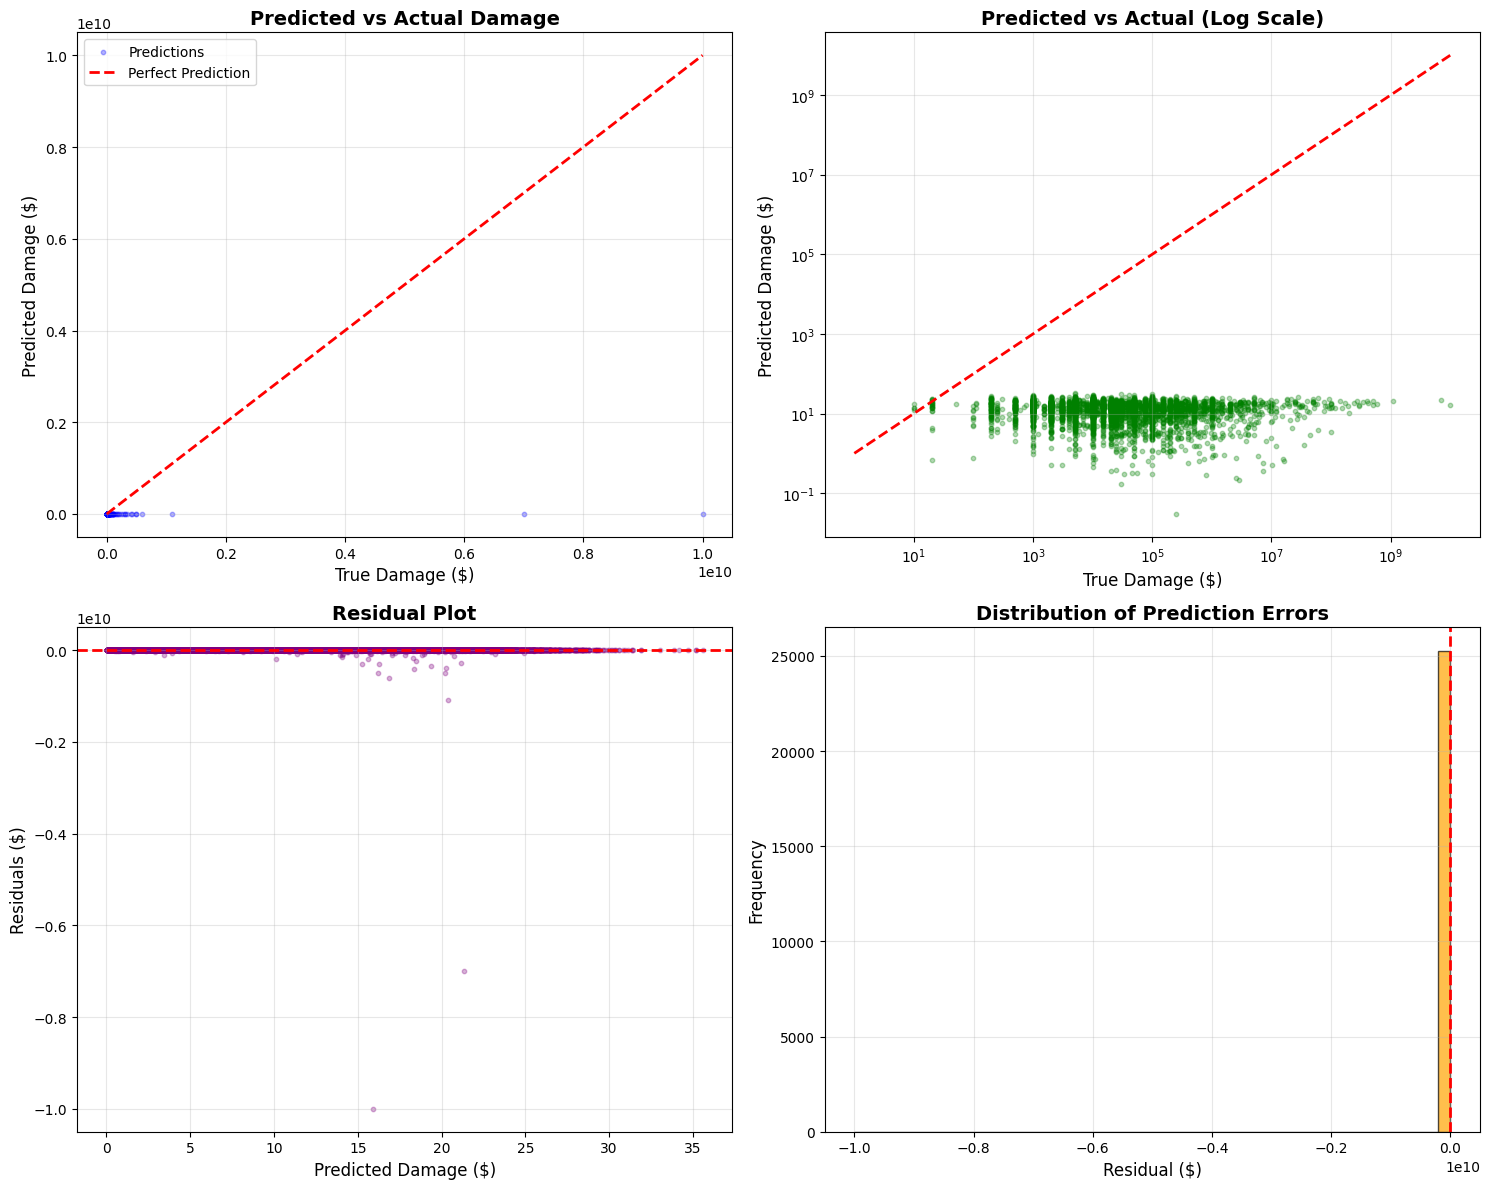

✓ Plot 'predictions_analysis.png' salvato


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

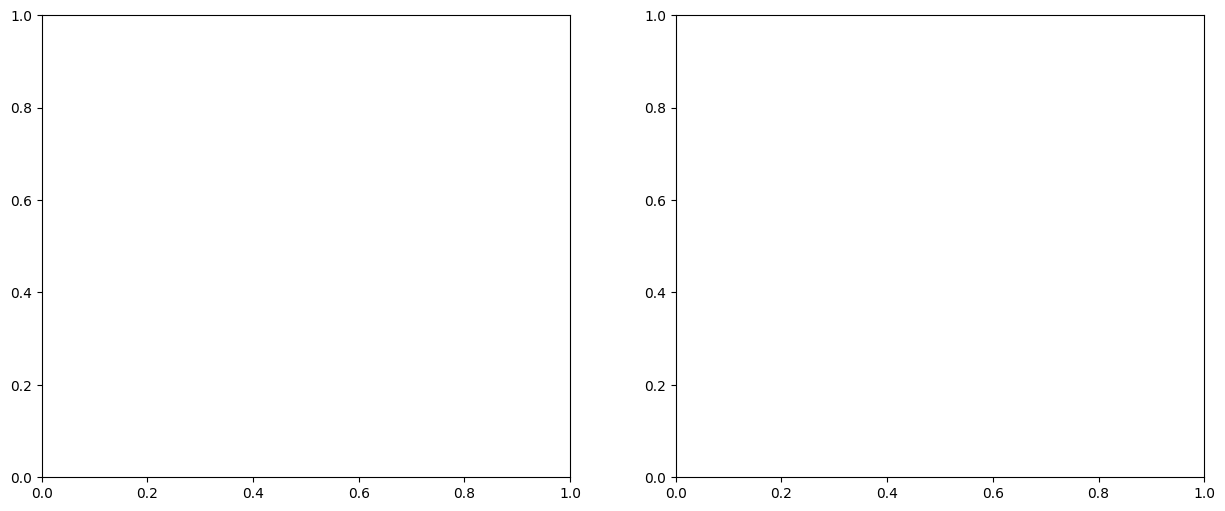

In [60]:
# ===== PLOT 1: Predicted vs Actual =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1.1: Scatter plot (scala normale)
ax1 = axes[0, 0]
ax1.scatter(true_np, pred_mean_np, alpha=0.3, s=10, c='blue', label='Predictions')
ax1.plot([true_np.min(), true_np.max()], 
         [true_np.min(), true_np.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Damage ($)', fontsize=12)
ax1.set_ylabel('Predicted Damage ($)', fontsize=12)
ax1.set_title('Predicted vs Actual Damage', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 1.2: Scatter plot (scala logaritmica)
ax2 = axes[0, 1]
# Filtra valori > 0 per log scale
mask_pos = (true_np > 0) & (pred_mean_np > 0)
ax2.scatter(true_np[mask_pos], pred_mean_np[mask_pos], alpha=0.3, s=10, c='green')
ax2.plot([1, true_np.max()], [1, true_np.max()], 'r--', linewidth=2)
ax2.set_xlabel('True Damage ($)', fontsize=12)
ax2.set_ylabel('Predicted Damage ($)', fontsize=12)
ax2.set_title('Predicted vs Actual (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Plot 1.3: Residual plot
ax3 = axes[1, 0]
residuals = pred_mean_np - true_np
ax3.scatter(pred_mean_np, residuals, alpha=0.3, s=10, c='purple')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Damage ($)', fontsize=12)
ax3.set_ylabel('Residuals ($)', fontsize=12)
ax3.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 1.4: Distribution of errors
ax4 = axes[1, 1]
ax4.hist(residuals, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Residual ($)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 'predictions_analysis.png' salvato")

# ===== PLOT 2: Uncertainty Quantification =====
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 2.1: Prediction intervals
ax1 = axes[0]
# Ordina per valori veri per visualizzazione più chiara
sort_idx = np.argsort(true_np)
true_sorted = true_np[sort_idx][:1000]  # Mostra solo 1000 punti per chiarezza
pred_sorted = pred_mean_np[sort_idx][:1000]
q05_sorted = q05_dollars.squeeze().numpy()[sort_idx][:1000]
q95_sorted = q95_dollars.squeeze().numpy()[sort_idx][:1000]

x_plot = np.arange(len(true_sorted))
ax1.fill_between(x_plot, q05_sorted, q95_sorted, alpha=0.3, color='lightblue', 
                  label='90% Prediction Interval')
ax1.plot(x_plot, true_sorted, 'o', markersize=3, alpha=0.5, color='red', label='True Damage')
ax1.plot(x_plot, pred_sorted, '-', linewidth=1, color='blue', label='Mean Prediction')
ax1.set_xlabel('Sample (sorted by true damage)', fontsize=12)
ax1.set_ylabel('Damage ($)', fontsize=12)
ax1.set_title('Prediction Intervals (90% CI)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2.2: Calibration plot
ax2 = axes[1]
# Calcola coverage empirico per diversi livelli di confidenza
confidence_levels = np.arange(0.1, 1.0, 0.1)
empirical_coverage = []

for conf in confidence_levels:
    lower_q = (1 - conf) / 2
    upper_q = 1 - lower_q
    
    quantiles_temp = torch.quantile(
        predicted_samples,
        torch.tensor([lower_q, upper_q]),
        dim=0
    )
    lower_bound = denormalize_damage(quantiles_temp[0]).squeeze().numpy()
    upper_bound = denormalize_damage(quantiles_temp[1]).squeeze().numpy()
    
    # Conta quanti valori veri cadono nell'intervallo
    in_interval = (true_np >= lower_bound) & (true_np <= upper_bound)
    coverage = in_interval.mean()
    empirical_coverage.append(coverage)

ax2.plot(confidence_levels * 100, np.array(empirical_coverage) * 100, 
         'o-', linewidth=2, markersize=8, label='Empirical Coverage')
ax2.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Calibration')
ax2.set_xlabel('Nominal Confidence Level (%)', fontsize=12)
ax2.set_ylabel('Empirical Coverage (%)', fontsize=12)
ax2.set_title('Calibration Plot', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 100])
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('uncertainty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 'uncertainty_analysis.png' salvato")

# ===== PLOT 3: Esempi di Predizioni Specifiche =====
print("\n" + "="*60)
print("ESEMPI DI PREDIZIONI SPECIFICHE")
print("="*60)

# Seleziona 5 esempi interessanti
# 1. Danno minimo
# 2. Danno mediano
# 3. Danno alto
# 4. Caso dove il modello ha predetto bene
# 5. Caso dove il modello ha sbagliato molto

idx_min = np.argmin(true_np)
idx_median = np.argsort(true_np)[len(true_np)//2]
idx_high = np.argmax(true_np)

# Caso con errore minimo
errors = np.abs(true_np - pred_mean_np)
idx_good = np.argmin(errors)

# Caso con errore massimo
idx_bad = np.argmax(errors)

example_indices = [idx_min, idx_median, idx_high, idx_good, idx_bad]
example_labels = ['Minimum Damage', 'Median Damage', 'Maximum Damage', 
                  'Best Prediction', 'Worst Prediction']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (idx, label) in enumerate(zip(example_indices, example_labels)):
    ax = axes[i]
    
    # Ottieni samples per questo evento
    samples = predicted_samples[:, idx, 0].numpy()
    samples_dollars = denormalize_damage(torch.tensor(samples)).numpy()
    
    # Plot histogram
    ax.hist(samples_dollars, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Aggiungi linee verticali
    ax.axvline(true_np[idx], color='red', linewidth=2, linestyle='--', 
               label=f'True: ${true_np[idx]:,.0f}')
    ax.axvline(pred_mean_np[idx], color='blue', linewidth=2, linestyle='-', 
               label=f'Pred: ${pred_mean_np[idx]:,.0f}')
    
    ax.set_xlabel('Damage ($)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('example_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 'example_predictions.png' salvato")

# ===== Stampa esempi numerici =====
print("\nEsempi di predizioni dettagliate:\n")
for idx, label in zip(example_indices, example_labels):
    print(f"{label}:")
    print(f"  True damage: ${true_np[idx]:,.2f}")
    print(f"  Predicted mean: ${pred_mean_np[idx]:,.2f}")
    print(f"  Predicted std: ${pred_std_dollars.squeeze().numpy()[idx]:,.2f}")
    print(f"  90% CI: [${q05_dollars.squeeze().numpy()[idx]:,.2f}, "
          f"${q95_dollars.squeeze().numpy()[idx]:,.2f}]")
    print(f"  Error: ${abs(true_np[idx] - pred_mean_np[idx]):,.2f}\n")
